In [1]:
# Install atlasopenmagic. --user is only required on SWAN, but shouldn't cause issues elsewhere.
%pip install --user atlasopenmagic

Note: you may need to restart the kernel to use updated packages.


In [2]:
# SWAN does not include the local package installation in the PYTHONPATH, so we work around this.
# Again, this shouldn't cause issues elsewhere.
import sys
import os
sys.path += [ f'{os.environ["HOME"]}/.local/lib/python{sys.version_info.major}.{sys.version_info.minor}/site-packages' ]

# We can now safely import atlasopenmagic and install its recommended packages
import atlasopenmagic
atlasopenmagic.install_from_environment()

Installing packages: ['aiohttp>=3.9.5', 'atlasopenmagic>=1.2.0', 'awkward>=2.6.7', 'awkward-pandas>=2023.8.0', 'coffea~=0.7.0', 'fsspec>=2025.7.0', 'hist>=2.8.0', 'ipykernel>=6.29.5', 'jupyter>=1.0.0', 'lmfit>=1.3.2', 'matplotlib>=3.9.1', 'metakernel>=0.30.2', 'notebook<7', 'numpy>=1.26.4', 'pandas>=2.2.2', 'papermill>=2.6.0', 'pip>=24.2', 'scikit-learn>=1.5.1', 'uproot>=5.3.10', 'uproot3>=3.14.4', 'fsspec-xrootd>=0.5.1', 'jupyterlab_latex~=3.1.0', 'vector>=1.4.1']
  Using cached coffea-0.7.31-py2.py3-none-any.whl.metadata (9.6 kB)
  Using cached ipykernel-6.31.0-py3-none-any.whl.metadata (4.5 kB)
INFO: pip is looking at multiple versions of coffea to determine which version is compatible with other requirements. This could take a while.
  Using cached coffea-0.7.30-py2.py3-none-any.whl.metadata (9.6 kB)
  Using cached coffea-0.7.29-py2.py3-none-any.whl.metadata (9.6 kB)
  Using cached coffea-0.7.28-py2.py3-none-any.whl.metadata (9.6 kB)
  Using cached coffea-0.7.27-py2.py3-none-any.wh

In [3]:
# File reading libraries
import uproot
import atlasopenmagic as atom
# Analysis libraries
import awkward as ak
import numpy as np
# Utility libraries
import matplotlib.pyplot as plt
import matplotlib
# Change our plotting font to sans serif, for aesthetics!
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica","Arial","Nimbus Sans","DejaVu Sans"],
    "svg.fonttype": "path"
})
from tqdm import tqdm
import time

In [4]:
# - Useful plotting functions - #
# Use innerward facing ticks in all direction
def inner_ticks(ax:matplotlib.axes.Axes):
    ax.tick_params(direction="in",which="both",top=True,right=True)

# Plot an ATLAS Open Data label on a pair of axes
def atlas_label(ax:matplotlib.axes.Axes,loc="upper right",text="Open Data",fontsize=16,pos_ovr=None,msg=""):
    locs = {
        "upper left" : (.04, .88),
        "upper right": (.96, .88),
    }
    if (pos_ovr is not None) and isinstance(pos_ovr,tuple):
        pos = pos_ovr 
    else: pos = locs[loc]
    align = ("left","right","center"); ha = "left"
    for a in align:
        if a in loc: ha = a
    ax.text(
        *pos,r"$\mathbfit{ATLAS}$ "+text,
        transform=ax.transAxes,fontsize=fontsize,ha=ha,va="bottom"
    )
    if msg:
        ax.text(
            pos[0], pos[1]-.05, msg,
            transform=ax.transAxes, fontsize=fontsize*.75, ha=ha, va="bottom"
        )

In [5]:
# Fetch minimum bias heavy ion collision data
atom.set_release("2024r-hi")
sample_defs = {
    "Data": {'dids': ["data"], 'color': 'red'}
}
data_samples = atom.build_dataset(sample_defs,skim="noskim",protocol="https",cache=True)

Fetching and caching all metadata for release: 2024r-hi...
Successfully cached 2 datasets.
Active release: 2024r-hi. (Datasets path: REMOTE)


In [6]:
# Histogram parameters for the FCal total transverse energy histogram which we want to fill
h_def = {
    "bin_width": 20e3, # MeV
    "range": (0,5e6) # MeV
}
h_def["n_bins"] = int((h_def["range"][1] - h_def["range"][0]) / h_def["bin_width"])
# Initialise an empty total ET histogram
h_total_eT, h_def["bin_edges"] = np.histogram([-1],h_def["n_bins"],h_def["range"])

In [7]:
# Take a url and grab the total transverse energy histogram from its ROOT file
def grab_hist_from_file(url:str)->np.ndarray:
    with uproot.open(f"{url}:CollectionTree") as tree:
        fcal = ak.zip({
        branch.split(".")[1]: tree[branch].array() for branch in (
            f"EventInfoAuxDyn.FCalEt{x}" for x in ("A","C")
        )})
        fcal["TotalEt"] = fcal["FCalEtA"] + fcal["FCalEtC"]
        this_hist,_ = np.histogram(fcal["TotalEt"],bins=h_def["n_bins"],range=h_def["range"])
    return this_hist

# Converts a numpy histogram into a sparkline histogram
# Allows us to watch our histogram fill in real time!
blocks = " ▁▂▃▄▅▆▇█"
def to_sparkline(hist:np.ndarray,lim=20)->str:
    if len(hist) > lim: # Trim the histogram if it is too large, taking evenly-spaced bins along it
        hist = np.array([hist[int( (len(hist)-1)*i/lim )] for i in range(lim)])
    if np.max(hist)==0:
        return blocks[0]*len(hist)
    norm = hist / np.max(hist)
    return f'{"".join(blocks[int(v * (len(blocks) - 1))] for v in norm)} Events: {int(np.sum(hist))}'

In [8]:
start = time.time()
print("Processing datasets...")
pbar = tqdm(data_samples["Data"]["list"][:20],desc=to_sparkline(h_total_eT))
for url in pbar:
    h_total_eT = h_total_eT + grab_hist_from_file(url)
    # Update progress bar histogram
    pbar.set_description(to_sparkline(h_total_eT))
end = time.time()
print(f"Total time: {round((end - start) / 60, 1)} mins")

Processing datasets...


                    :   0%|          | 0/20 [00:00<?, ?it/s]

█                    Events: 60664: 100%|██████████| 20/20 [01:34<00:00,  4.74s/it]

Total time: 1.6 mins


Text(0, 0.5, '$\\mathrm{d}N/\\mathrm{d}E_{\\mathrm{T}}$ [TeV$^{-1}$]')

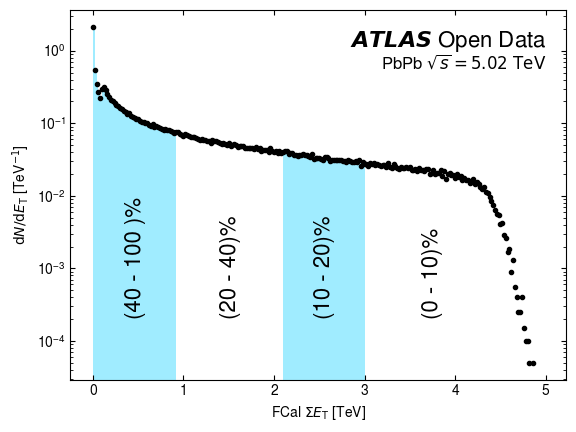

In [10]:
TeV = 1e-6
fig, ax = plt.subplots()
# Calculate the differential histogram by diving by the bin width
h_diff = h_total_eT / h_def["bin_width"]

# Flip our histogram and take its cumulative sum
# Then, normalise this
# Doing so will produce an array from 0. -> 1. with high centrality collisions at the beginning
norm_cum_int = np.cumsum(np.flip(h_total_eT[h_total_eT!=0])) / np.sum(h_total_eT)

# Define centrality ranges
centrality_ranges = {
    40: "40 - 100 %",
    20: "20 - 40%",
    10: "10 - 20%",
    0: "0 - 10%"
}
labels = [
    "(40 - 100 )%",
    "(20 - 40)%",
    "(10 - 20)%",
    "(0 - 10)%"
]
# Set the index of the first centrality range to be zero
centrality_ix = [0]
# Then calculate the other indices of the centrality ranges by finding the index closest to the centrality,
# e.g. closest index to .02 for the start of the 20 - 40% range.
centrality_ix += [np.argmin(np.abs(np.flip(norm_cum_int) - c*.01)) for c in centrality_ranges]
# Iterate over the centrality ranges and fill histograms in their ranges.
# This approximates filling the areas under the curves.
for i,col in zip(range(len(centrality_ranges)),("#2cd5ff73","white","#2cd5ff73","white")):
    ixmin, ixmax = centrality_ix[i], centrality_ix[i+1]
    ax.stairs(h_diff[centrality_ix[i]:centrality_ix[i+1]-1],h_def["bin_edges"][ixmin:ixmax]*TeV,fill=True,color=col)

    A = .5 if labels[i]!="(0 - 10)%" else .4
    ax.text((h_def["bin_edges"][ixmin]+(h_def["bin_edges"][ixmax]-h_def["bin_edges"][ixmin])*A)*TeV,20e-5,labels[i],rotation=90,fontsize=16,ha="center",va="bottom")
ax.scatter(h_def["bin_edges"][:-1]*TeV,h_diff,color="black",marker=".")

ax.set_yscale("log")
atlas_label(ax,msg=r"PbPb $\sqrt{s}=5.02\ \mathrm{TeV}$")
inner_ticks(ax)
ax.set_xlabel(r"FCal $\Sigma E_\mathrm{T}$ [TeV]"); ax.set_ylabel(r"$\mathrm{d}N/\mathrm{d}E_{\mathrm{T}}$ [TeV$^{-1}$]")